## 11/7 ge calibration - DPR1-L-120-35

ge_freq = (8.2779 -0.001898495)e9

ge_pi_amp = 0.7505456737244419


T1 = 5.285948679781458e-08

T2 = 8.14e-06

T2_star = 4.19e-06

In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit

In [2]:
import sklearn
from sklearn.decomposition import PCA

In [3]:
def Rabi(delay, amp, phi0, detun, const):
    return - amp * np.cos(2*np.pi*detun*delay+phi0) + const

In [4]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [5]:
header = "D:/K_Sunada/result/CDY151/"

In [6]:
amp = "/2023-11-07/2023-11-07T160540_0f8e6b46-21_ge_pi_amp"
dd_amp = datadict_from_hdf5(header + amp +"/data")

In [7]:
Rabi_amp = dd_amp['s11']['values']
imag_amp = Rabi_amp.imag
amp = dd_amp['amplitude']['values']

In [8]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2, pca

In [12]:
I_amp = (Rabi_amp.real)
Q_amp = (Rabi_amp.imag)
PCA_amp = PCA_transform(I_amp, Q_amp)


In [17]:
PCA_amp = PCA_transform(I_amp, Q_amp)
PCA_amp[0]

array([ 1.15217434e-04,  1.41782868e-04,  1.27152726e-04,  9.89008768e-05,
        7.31313471e-05,  7.87392405e-05,  6.68581479e-05,  5.28337357e-05,
        3.13997450e-05,  3.94527108e-05,  4.37198492e-06,  2.15384480e-05,
        1.65595812e-05, -2.53996834e-05, -4.59001257e-05, -8.22850682e-05,
       -7.10040105e-05, -2.50080866e-05, -5.47653971e-05, -5.35150791e-05,
       -3.87427127e-06, -2.31301281e-05, -3.02487232e-05, -5.55813489e-06,
        3.76686926e-05,  2.18309550e-05,  5.66358947e-06,  2.06373873e-05,
        5.49060912e-05,  8.08330198e-05,  4.07391372e-05,  8.07228136e-05,
        6.49376772e-05,  4.63305155e-05,  1.64835453e-05,  3.31940046e-05,
        2.55810022e-05,  1.78879831e-05, -2.09024565e-05, -3.41842084e-05,
       -3.61355549e-05, -5.86109619e-05, -4.05301723e-05, -8.07117651e-05,
       -2.91508277e-05, -2.35778673e-05, -6.72511024e-05, -1.09594950e-05,
        2.12048203e-06, -1.50946554e-05, -5.35021761e-06,  2.57690696e-05,
        2.43389025e-05,  

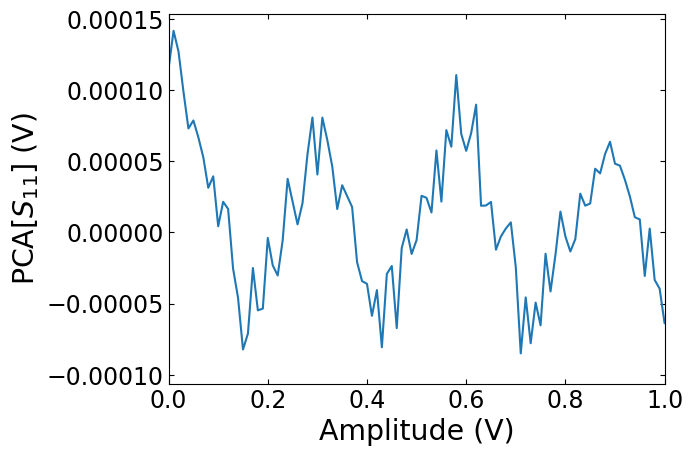

In [19]:
PCA_amp = PCA_transform(I_amp, Q_amp)
y = I_amp
x = amp

fig, (ax1) = plt.subplots(nrows=1)
ax1.set_xlabel('Amplitude (V)', size='large')
ax1.set_ylabel('PCA[$S_{11}$] (V)', size='large')
plt.rcParams["font.size"] = 17
plt.plot(x, PCA_amp[0])
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")
ax1.set_xlim(0, 1)
# ax1.set_ylim(-48, 160)
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )
plt.show()

In [30]:
par_ini= {
    'amp': 0.00015/2,
    'phi0':np.pi/2,
    'detun':1/0.3,
    'const':0
}

par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [31]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
    
result = model.fit(data = PCA_amp[0], params = params, delay = x)
result

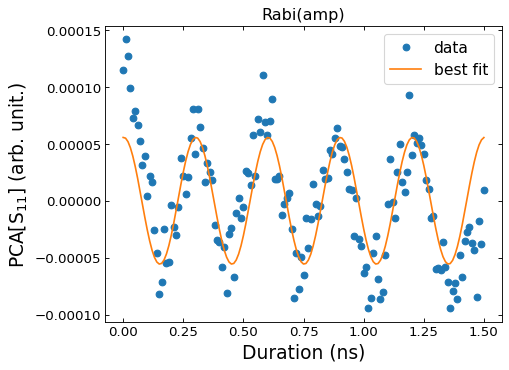

In [42]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(amp)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
# plt.plot(x,result.init_fit)

plt.rcParams["font.size"] = 14
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

# plt.plot(x_t1,result_t1.init_fit, label='init fit')

# ax.set_xlim(0, 250000)
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
ax.set_xlabel('Duration (ns)', size='large')
ax.set_ylabel('PCA[S$_{11}$] (arb. unit.)', size='large')

ax.legend()
plt.show()

In [33]:
np.pi/(3.33090988*2*np.pi)*5

0.7505456737244419

ramsey

In [54]:
pl = "/2023-09-14/2023-09-14T145010_9100daf2-td_ge_T2r1d"
mi = "/2023-09-14/2023-09-14T145128_bf48a593-td_ge_T2r1d"
dd_pl = datadict_from_hdf5(header + pl +"/data")
dd_mi = datadict_from_hdf5(header + mi +"/data")

In [55]:
Rabi_pl = dd_pl['s11']['values']
imag_pl = Rabi_pl.imag
delay_pl = dd_pl['delay']['values']

Rabi_mi = dd_mi['s11']['values']
imag_mi = Rabi_mi.imag
delay_mi = dd_mi['delay']['values']

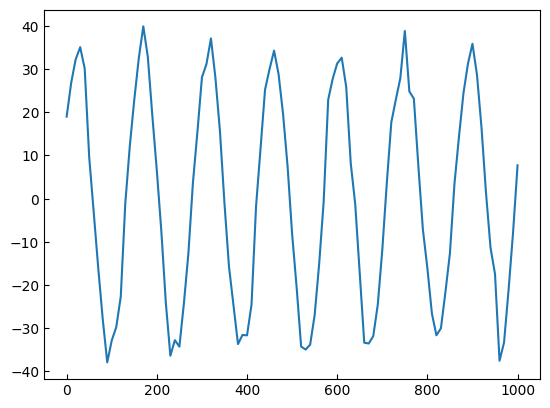

In [56]:
I_pl = (Rabi_pl.real)
Q_pl = (Rabi_pl.imag)
I_mi = (Rabi_mi.real)
Q_mi = (Rabi_mi.imag)


PCA_pl = PCA_transform(I_pl, Q_pl)
y_pl = PCA_pl[0]
x_pl = delay_pl

PCA_mi = PCA_transform(I_mi, Q_mi)
y_mi = PCA_mi[0]
x_mi = delay_mi



plt.plot(x_pl, y_pl)
plt.show()

In [57]:
par_ini_pl = {
    'amp': 35,
    'phi0':np.pi,
    'detun':1/150,
    'const':0
}

par_min_pl = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max_pl = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary_pl = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [58]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_pl[name],
    min = par_min_pl[name],
    max = par_max_pl[name],
    vary = par_vary_pl[name]
    )
    
result_pl = model.fit(data = y_pl, params = params, delay = x_pl)
result_pl

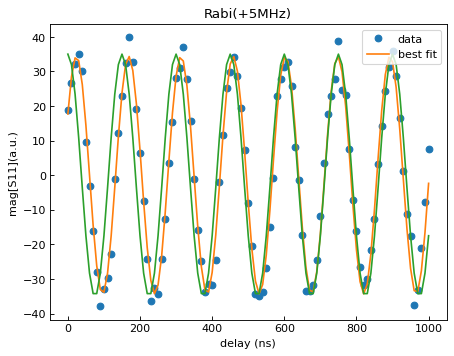

In [59]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(+5MHz)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_pl.plot_fit(ax = ax)
plt.plot(x_pl,result_pl.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")


plt.show()

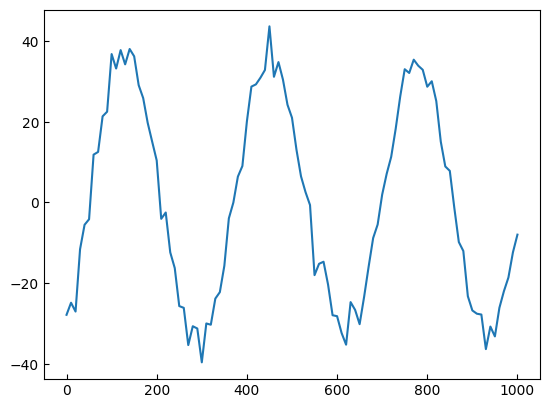

In [60]:
plt.plot(x_mi, y_mi)
plt.show()

In [61]:
par_ini_mi = {
    'amp': 40,
    'phi0':-np.pi/2,
    'detun':1/300,
    'const':0
}

par_min_mi = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max_mi = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary_mi = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [62]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_mi[name],
    min = par_min_mi[name],
    max = par_max_mi[name],
    vary = par_vary_mi[name]
    )
    
result_mi = model.fit(data = y_mi, params = params, delay = x_mi)
result_mi

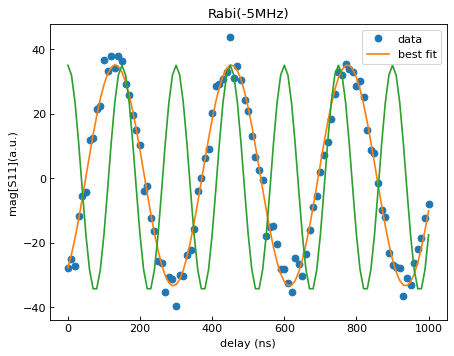

In [63]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(-5MHz)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_mi.plot_fit(ax = ax)
plt.plot(x_mi,result_pl.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")


plt.show()


In [64]:
detun = ((0.005-0.00690290)+ (0.00310591-0.005))/2 #GHz
detun

-0.001898495

drag

In [191]:
drag = "/2023-09-15/2023-09-15T152647_d8f7660a-td_ge_pi_drag"
dd_drag = datadict_from_hdf5(header + drag +"/data")

drag1 = "/2023-09-15/2023-09-15T152830_166689a7-td_ge_pi_drag"
dd_drag1 = datadict_from_hdf5(header + drag1 +"/data")

drag2 = "/2023-09-15/2023-09-15T153037_61d3963e-td_ge_pi_drag"
dd_drag2 = datadict_from_hdf5(header + drag2 +"/data")

In [192]:
Rabi_drag = dd_drag['s11']['values']
imag_drag = Rabi_drag.imag
drag = dd_drag['beta']['values']
I_drag = (Rabi_drag.real)
Q_drag = (Rabi_drag.imag)

Rabi_drag1 = dd_drag1['s11']['values']
imag_drag1 = Rabi_drag1.imag
drag1 = dd_drag1['beta']['values']
I_drag1 = (Rabi_drag1.real)
Q_drag1 = (Rabi_drag1.imag)

Rabi_drag2 = dd_drag2['s11']['values']
imag_drag2 = Rabi_drag2.imag
drag2 = dd_drag2['beta']['values']
I_drag2 = (Rabi_drag2.real)
Q_drag2 = (Rabi_drag2.imag)

In [193]:
def PCA_transform1(Re_c_amp, Im_c_amp, Re_c_drag, Im_c_drag):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c_amp]).T, np.array([Im_c_amp]).T], axis = 1)
    c1_data = np.concatenate([np.array([Re_c_drag]).T, np.array([Im_c_drag]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    
    c1_pca = pca.transform(c1_data)
    c1_PCA1 = c1_pca.T[0]
    c1_PCA2 = c1_pca.T[1]
    return c_PCA1, c_PCA2, c1_PCA1, c1_PCA2,

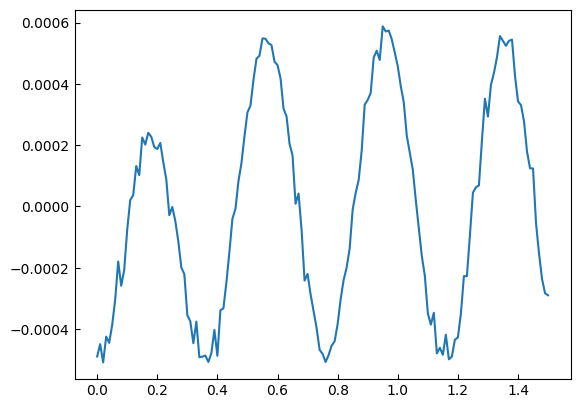

In [194]:
PCA_drag = PCA_transform1(I_amp, Q_amp, I_drag, Q_drag)
y = PCA_drag[0]
x = amp
y0 = PCA_drag[2]
x0 = drag

PCA_drag1 = PCA_transform1(I_amp, Q_amp, I_drag1, Q_drag1)
y1 = PCA_drag1[2]
x1 = drag1

PCA_drag2 = PCA_transform1(I_amp, Q_amp, I_drag2, Q_drag2)
y2 = PCA_drag2[2]
x2 = drag2


plt.plot(x, y)
plt.show()

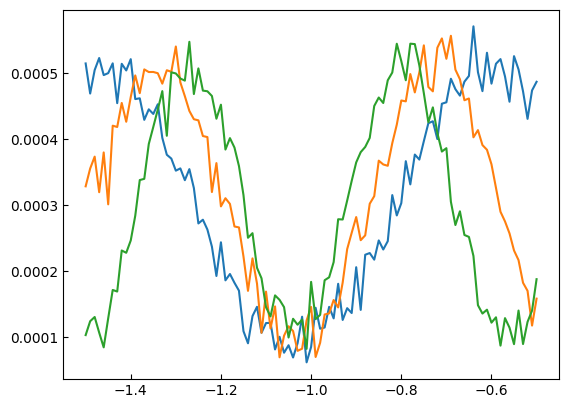

In [195]:
plt.plot(x0, y0)
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.show()

In [169]:
par_ini= {
    'amp': 0.0002,
    'phi0':np.pi/2,
    'detun':1/0.8,
    'const':0.0003
}

par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [170]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
    
result0 = model.fit(data = y0, params = params, delay = x0)
result1 = model.fit(data = y1, params = params, delay = x1)
result2 = model.fit(data = y2, params = params, delay = x2)

In [198]:
result0

In [201]:
res0 = (-2*np.pi-1.15104633)/(2*np.pi*1.14249168)
res0

-1.0356265466609655

In [203]:
result1

In [204]:
res1 = (-2*np.pi-	4.30230786)/(2*np.pi*1.63131373)
res1

-1.0327465107659664

In [179]:
result2

In [205]:
res2 = (-2*np.pi-6.28318531)/(2*np.pi*1.94716397)
res2

-1.027134864481332

In [207]:
beta = (res0 + res1 + res2)/3
beta

-1.0318359739694214

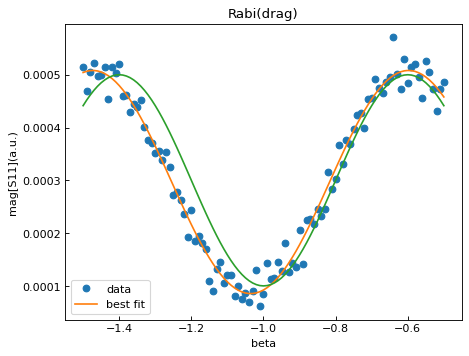

In [176]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result0.plot_fit(ax = ax)
plt.plot(x0,result0.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

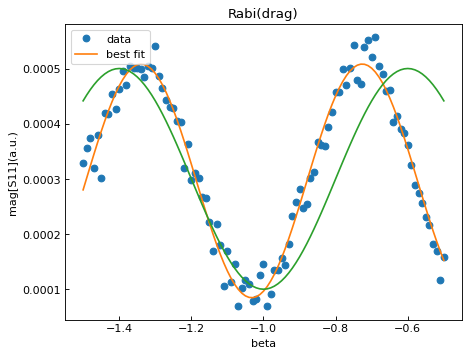

In [174]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result1.plot_fit(ax = ax)
plt.plot(x1,result1.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

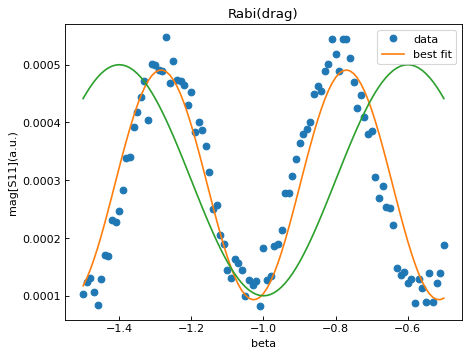

In [175]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result2.plot_fit(ax = ax)

plt.plot(x2,result2.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()


half drag

In [219]:
drag = "/2023-09-16/2023-09-16T151219_fdd17738-td_ge_pi_drag"
dd_drag = datadict_from_hdf5(header + drag +"/data")

drag1 = "/2023-09-16/2023-09-16T151407_3e0e7afb-td_ge_pi_drag"
dd_drag1 = datadict_from_hdf5(header + drag1 +"/data")

drag2 = "/2023-09-16/2023-09-16T151547_7a192eb2-td_ge_pi_drag"
dd_drag2 = datadict_from_hdf5(header + drag2 +"/data")

In [220]:
Rabi_drag = dd_drag['s11']['values']
imag_drag = Rabi_drag.imag
drag = dd_drag['beta']['values']
I_drag = (Rabi_drag.real)
Q_drag = (Rabi_drag.imag)

Rabi_drag1 = dd_drag1['s11']['values']
imag_drag1 = Rabi_drag1.imag
drag1 = dd_drag1['beta']['values']
I_drag1 = (Rabi_drag1.real)
Q_drag1 = (Rabi_drag1.imag)

Rabi_drag2 = dd_drag2['s11']['values']
imag_drag2 = Rabi_drag2.imag
drag2 = dd_drag2['beta']['values']
I_drag2 = (Rabi_drag2.real)
Q_drag2 = (Rabi_drag2.imag)

In [221]:
def PCA_transform1(Re_c_amp, Im_c_amp, Re_c_drag, Im_c_drag):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c_amp]).T, np.array([Im_c_amp]).T], axis = 1)
    c1_data = np.concatenate([np.array([Re_c_drag]).T, np.array([Im_c_drag]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    
    c1_pca = pca.transform(c1_data)
    c1_PCA1 = c1_pca.T[0]
    c1_PCA2 = c1_pca.T[1]
    return c_PCA1, c_PCA2, c1_PCA1, c1_PCA2,

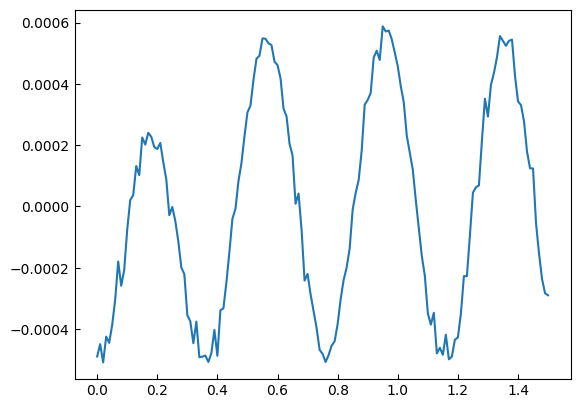

In [222]:
PCA_drag = PCA_transform1(I_amp, Q_amp, I_drag, Q_drag)
y = PCA_drag[0]
x = amp
y0 = PCA_drag[2]
x0 = drag

PCA_drag1 = PCA_transform1(I_amp, Q_amp, I_drag1, Q_drag1)
y1 = PCA_drag1[2]
x1 = drag1

PCA_drag2 = PCA_transform1(I_amp, Q_amp, I_drag2, Q_drag2)
y2 = PCA_drag2[2]
x2 = drag2


plt.plot(x, y)
plt.show()

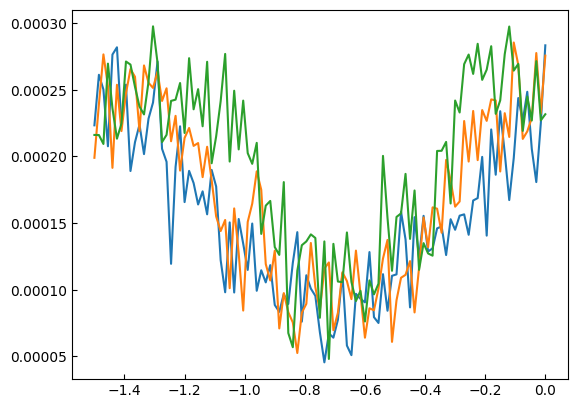

In [223]:
plt.plot(x0, y0)
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.show()

In [230]:
par_ini= {
    'amp': 0.0001,
    'phi0':np.pi,
    'detun':1/1.5,
    'const':0.00015
}

par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [231]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
    
result0 = model.fit(data = y0, params = params, delay = x0)
result1 = model.fit(data = y1, params = params, delay = x1)
result2 = model.fit(data = y2, params = params, delay = x2)

In [232]:
result0

In [239]:
res0 = (0-2.42785277)/(2*np.pi*0.55021086)
res0

-0.7022848830080353

In [233]:
result1

In [240]:
res1 = (0-3.09326300	)/(2*np.pi*0.70094528)
res1

-0.7023488291885859

In [234]:
result2

In [241]:
res2 = (0-3.69712872)/(2*np.pi*0.86133295)
res2

-0.6831461759764466

In [243]:
beta = (res0 + res1 + res2)/3
beta

-0.6959266293910226

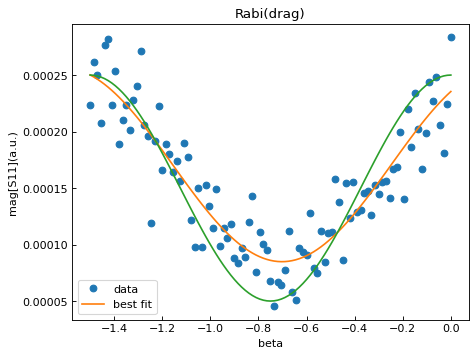

In [235]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result0.plot_fit(ax = ax)
plt.plot(x0,result0.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

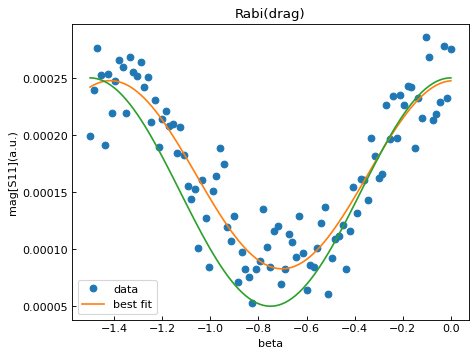

In [236]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result1.plot_fit(ax = ax)
plt.plot(x1,result1.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

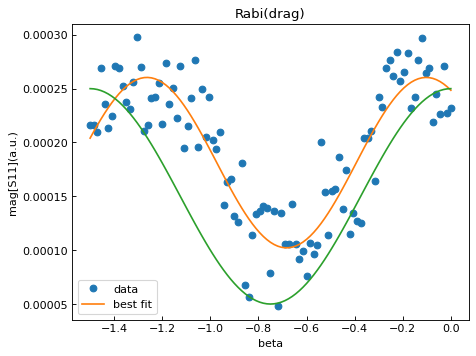

In [237]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result2.plot_fit(ax = ax)

plt.plot(x2,result2.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()


T1

In [34]:
def Dephase(delay, amp, gamma, const):
    return amp*np.exp(-gamma*delay) + const

t1 ="/2023-11-07/2023-11-07T163002_76dcb5e3-24_ge_T1"

dd_t1 = datadict_from_hdf5(header + t1 +"/data")

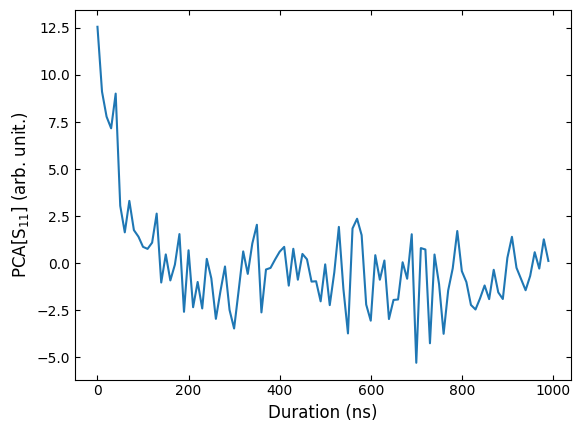

In [37]:
s11_t1 = dd_t1['s11']['values'][0:100]
imag_t1 = s11_t1.imag
delay_t1 = dd_t1['delay']['values'][0:100]

I_t1 = (s11_t1.real)
Q_t1 = (s11_t1.imag)
ang_t1 = np.angle(s11_t1)

PCA_t1 = PCA_transform(I_t1, Q_t1)

y_t1 = PCA_t1[0]
x_t1 = delay_t1

fig, (ax1) = plt.subplots(nrows=1)
ax1.set_xlabel('Duration (ns)', size='large')
ax1.set_ylabel('PCA[S$_{11}$] (arb. unit.)', size='large')
plt.rcParams["font.size"] = 10
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")
# ax1.set_xlim(0, 250000)
# ax1.set_ylim(-48, 160)
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

plt.plot(x_t1, y_t1)
plt.show()

In [38]:
par_ini_t1 = {
    'gamma': 1/180,
    'amp':14.5,
    'const':0
}

par_min_t1 = {
    'gamma': 0,
    'amp':0,
    'const':-np.inf
}

par_max_t1 = {
    'gamma': np.inf,
    'amp':np.inf,
    'const':np.inf,
}

par_vary_t1 = {
    'gamma': True,
    'amp':True,
    'const':True
}

In [39]:
model = lmfit.Model(Dephase)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t1[name],
    min = par_min_t1[name],
    max = par_max_t1[name],
    vary = par_vary_t1[name]
    )
result_t1 = model.fit(data = y_t1, params = params, delay = x_t1)
result_t1

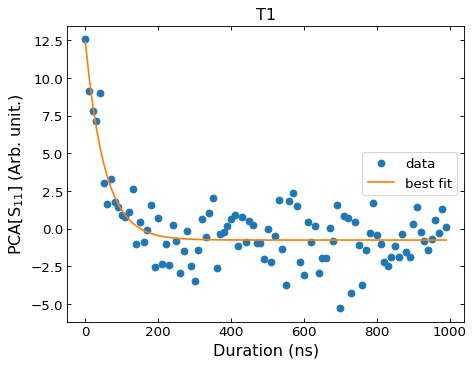

In [44]:
fig, (ax) = plt.subplots(dpi=80)
plt.title("T1")


plt.rcParams["font.size"] = 12
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

result_t1.plot_fit(ax = ax)
# plt.plot(x_t1,result_t1.init_fit, label='init fit')

# ax.set_xlim(0, 250000)
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
ax.set_xlabel('Duration (ns)', size='large')
ax.set_ylabel('PCA[S$_{11}$] (Arb. unit.)', size='large')

plt.legend(loc=7)
plt.show()

In [41]:
T1 = (1/0.01891808)*1e-9	
T1

5.285948679781458e-08

T2_star

In [76]:
t2e = "/2023-09-14/2023-09-14T150552_c28205f5-td_ge_T2e"
dd_t2e = datadict_from_hdf5(header + t2e +"/data")

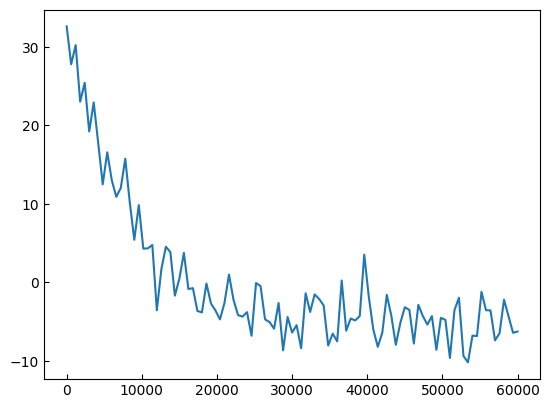

In [77]:
s11_t2e = dd_t2e['s11']['values']
imag_t2e = s11_t2e.imag
delay_t2e = dd_t2e['delay']['values']

I_t2e = (s11_t2e.real)
Q_t2e = (s11_t2e.imag)

PCA_t2e = PCA_transform(I_t2e, Q_t2e)

y_t2e = PCA_t2e[0]
x_t2e = delay_t2e

plt.plot(x_t2e, y_t2e)
plt.show()

In [78]:
par_ini_t2e = {
    'gamma': 1/2000,
    'amp':35,
    'const':0
}

par_min_t2e = {
    'gamma': 0,
    'amp':0,
    'const':-np.inf
}

par_max_t2e = {
    'gamma': np.inf,
    'amp':np.inf,
    'const':np.inf,
}

par_vary_t2e = {
    'gamma': True,
    'amp':True,
    'const':True
}

In [79]:
model = lmfit.Model(Dephase)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t2e[name],
    min = par_min_t2e[name],
    max = par_max_t2e[name],
    vary = par_vary_t2e[name]
    )
result_t2e = model.fit(data = y_t2e, params = params, delay = x_t2e)
result_t2e

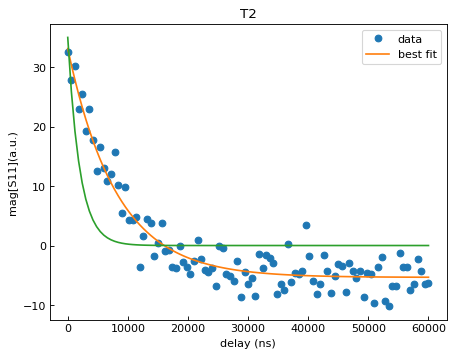

In [80]:
fig, ax = plt.subplots(dpi=80)

plt.title("T2")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t2e.plot_fit(ax = ax)
plt.plot(delay_t2e,result_t2e.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")

plt.show()

In [81]:
T2 = (1/1.2283e-04)*1e-9	
T2

8.141333550435562e-06

T2 star

In [82]:
def Damping(delay, amp, gamma, omega, phi0, const):
    return const + amp * np.exp(- gamma*delay)*np.cos(omega*delay + phi0)

In [83]:
t2 = "/2023-09-14/2023-09-14T151044_703fc5ec-td_ge_T2r1d"
dd_t2 = datadict_from_hdf5(header + t2 +"/data")

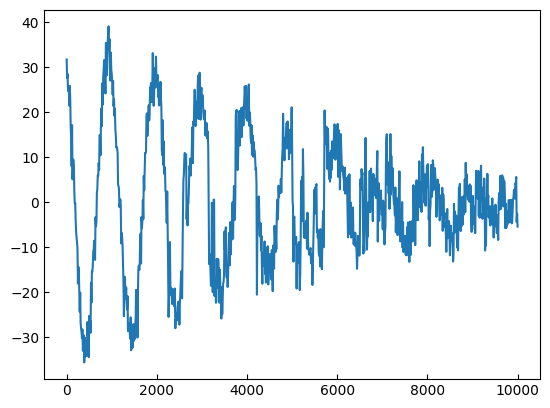

In [84]:
s11_t2 = dd_t2['s11']['values']
imag_t2 = s11_t2.imag
delay_t2 = dd_t2['delay']['values']

I_t2 = (s11_t2.real)
Q_t2 = (s11_t2.imag)

PCA_t2 = PCA_transform(I_t2, Q_t2)

y_t2 = PCA_t2[0]
x_t2 = delay_t2

plt.plot(x_t2, y_t2)
plt.show()

In [85]:
par_ini_t2 = {
    'amp':42,
    'gamma': 1/6000,
    'omega':2*np.pi/1000,
    'phi0':0,
    'const':0
}

par_min_t2 = {
    'amp':-np.inf,
    'gamma': 0,
    'omega':-2*np.pi,
    'phi0':-2*np.pi,
    'const':-np.inf
}

par_max_t2 = {
    'amp':np.inf,
    'gamma': np.inf,
    'omega':2*np.pi,
    'phi0':2*np.pi,
    'const':np.inf
}

par_vary_t2 = {
    'amp':True,
    'gamma': True,
    'omega':True,
    'phi0':True,
    'const':True
}

In [86]:
model = lmfit.Model(Damping)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t2[name],
    min = par_min_t2[name],
    max = par_max_t2[name],
    vary = par_vary_t2[name]
    )
result_t2 = model.fit(data = y_t2, params = params, delay = x_t2)
result_t2

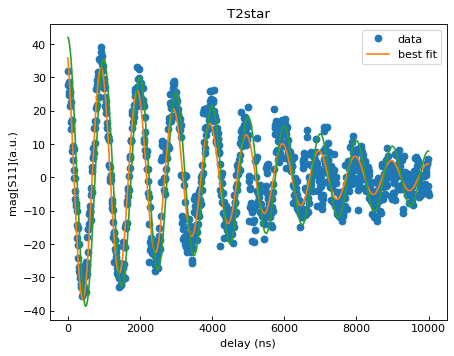

In [87]:
fig, ax = plt.subplots(dpi=80)

plt.title("T2star")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t2.plot_fit(ax = ax)
plt.plot(delay_t2,result_t2.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")

plt.show()

In [88]:
T2_star = (1/2.3884e-04)*1e-9	
T2_star

4.186903366270306e-06